#K-Means Clustering (Unsupervised Learning)

In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd

##Load dataset

In [2]:
iris = load_iris()

In [3]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [4]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

##Convert to dataframe

In [5]:
df = pd.DataFrame(iris.data)
df

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


##Let's use two columns

In [6]:
df = df.drop([0,1],axis='columns')

In [7]:
df

,2,3
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


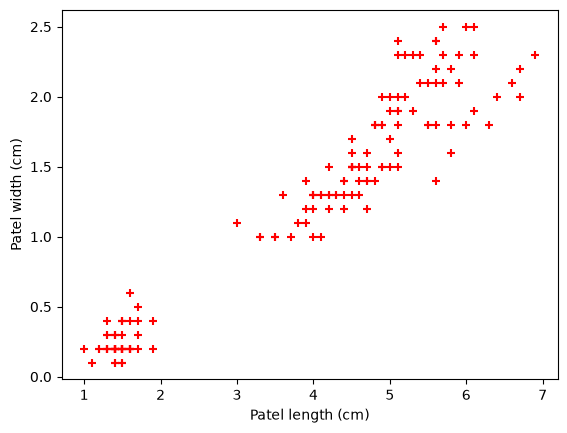

In [8]:
plt.scatter(df[2], df[3] , color = 'red', marker = '+')
plt.xlabel('Patel length (cm)')
plt.ylabel('Patel width (cm)')
plt.show()

## 🔬 Scale a Single Feature Using MinMaxScaler

In this step, we apply `MinMaxScaler` to scale a specific feature of the dataset.

### 🧮 Why MinMaxScaler?
- It scales values **between 0 and 1** (or a custom range).
- Useful for algorithms that are sensitive to feature magnitude (e.g., KMeans, SVM, Neural Networks).


In [9]:
s_length = MinMaxScaler()
s_length.fit(df[[2]])
df[2] = s_length.transform(df[[2]])

df

,2,3
0,0.067797,0.2
1,0.067797,0.2
2,0.050847,0.2
3,0.084746,0.2
4,0.067797,0.2
...,...,...
145,0.711864,2.3
146,0.677966,1.9
147,0.711864,2.0
148,0.745763,2.3


In [10]:
s_width = MinMaxScaler()
s_width.fit(df[[3]])
df[3] = s_width.transform(df[[3]])

df

,2,3
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667
...,...,...
145,0.711864,0.916667
146,0.677966,0.750000
147,0.711864,0.791667
148,0.745763,0.916667


In [11]:
model = KMeans(n_clusters=2)
y_predicted = model.fit_predict(df[[2,3]])

y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [12]:
df['predicted'] = y_predicted

df

,2,3,predicted
0,0.067797,0.041667,0
1,0.067797,0.041667,0
2,0.050847,0.041667,0
3,0.084746,0.041667,0
4,0.067797,0.041667,0
...,...,...,...
145,0.711864,0.916667,1
146,0.677966,0.750000,1
147,0.711864,0.791667,1
148,0.745763,0.916667,1


In [13]:
df1 = df[df['predicted']==0]
df2 = df[df['predicted']==1]

print(df1)
print(df2)

           2         3  predicted
0   0.067797  0.041667          0
1   0.067797  0.041667          0
2   0.050847  0.041667          0
3   0.084746  0.041667          0
4   0.067797  0.041667          0
5   0.118644  0.125000          0
6   0.067797  0.083333          0
7   0.084746  0.041667          0
8   0.067797  0.041667          0
9   0.084746  0.000000          0
10  0.084746  0.041667          0
11  0.101695  0.041667          0
12  0.067797  0.000000          0
13  0.016949  0.000000          0
14  0.033898  0.041667          0
15  0.084746  0.125000          0
16  0.050847  0.125000          0
17  0.067797  0.083333          0
18  0.118644  0.083333          0
19  0.084746  0.083333          0
20  0.118644  0.041667          0
21  0.084746  0.125000          0
22  0.000000  0.041667          0
23  0.118644  0.166667          0
24  0.152542  0.041667          0
25  0.101695  0.041667          0
26  0.101695  0.125000          0
27  0.084746  0.041667          0
28  0.067797  

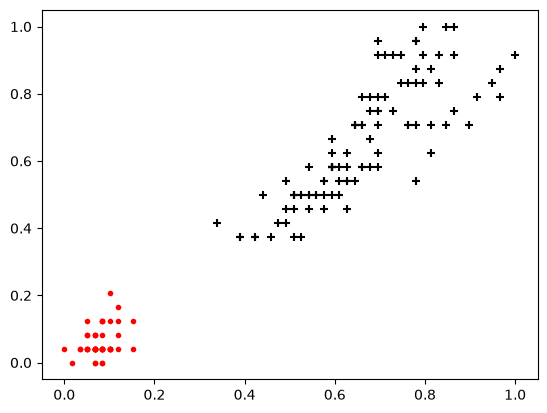

In [14]:
plt.scatter(df1[2], df1[3], color = 'red' , marker ='.')
plt.scatter(df2[2], df2[3], color = 'black' , marker ='+')
plt.show()

In [15]:
df = pd.DataFrame(iris.data)
df


,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [16]:
length = len(df.columns)
length

4

## 📉 Calculate SSE for Different Cluster Counts (Elbow Method)


In [17]:
sse =[]
for i in range(1,length+1):
    km = KMeans(n_clusters=i)
    km.fit(df)
    sse.append(km.inertia_)

print(sse)

[681.3706, 152.34795176035792, 78.851441426146, 57.26561904761905]


## 🧠 What is the Elbow Method?

The **Elbow Method** is a popular technique used to determine the **optimal number of clusters (K)** for KMeans clustering.

### 📊 How It Works:
1. **KMeans** is applied to the data for a range of values of K (e.g., 1 to 10).
2. For each K, the **SSE (Sum of Squared Errors)** is computed, which represents the compactness of the clusters.
   - This is also called **inertia_** in scikit-learn's KMeans.
3. A line plot is made:  
   - **X-axis**: number of clusters (K)  
   - **Y-axis**: SSE value for each K

### 🎯 Interpretation:
- As the number of clusters increases, SSE naturally decreases.
- At some point, the **rate of decrease sharply slows down**—forming an “elbow” in the plot.
- The **K at this elbow point** is considered the optimal number of clusters because it balances **model complexity and clustering performance**.

The method helps avoid overfitting while achieving good grouping of the data.


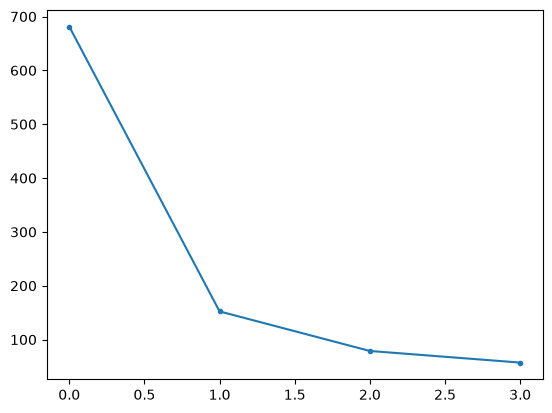

In [18]:
plt.plot(range(length),sse)
plt.scatter(range(length),sse, marker ='.')
plt.show()

##What did you identify from the elbow method? Use elbow method to identify the number of clusters and try applying K-Means on that number of clusters.

In [19]:
#Code here

In [20]:
sse = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(df)
    sse.append(km.inertia_)

print(sse)

[681.3706, 152.34795176035792, 78.85566582597728, 57.350880212954756, 46.472230158730156, 39.066035353535355, 34.3058152958153, 30.476222943722945, 29.906246659137967, 28.545297810033105]
